In [1]:
import sys
sys.path.append('..')
import os

import awkward as ak
import numpy as np
import uproot as uproot
import matplotlib.pyplot as plt
import mplhep as hep
import vector as vec
import matplotlib
from tqdm import tqdm

from Timing.plotting import *

from numba import prange

plt.style.use(hep.style.CMS)
%matplotlib inline

In [2]:
def load_branch_with_highest_cycle(file, branch_name):
    # Get all keys in the file
    all_keys = file.keys()
    # Filter keys that match the specified branch name
    matching_keys = [key for key in all_keys if key.startswith(branch_name)]
    if not matching_keys:
        raise ValueError(f"No branch with name '{branch_name}' found in the file.")
    # Find the key with the highest cycle
    highest_cycle_key = max(matching_keys, key=lambda key: int(key.split(";")[1]))
    # Load the branch with the highest cycle
    branch = file[highest_cycle_key]
    return branch

In [3]:
simTsKeys = [
 'regressed_energy',
 'raw_energy',
 # 'raw_em_energy',
 # 'raw_pt',
 # 'raw_em_pt',
 # 'barycenter_x',
 # 'barycenter_y',
 'barycenter_z',
 'barycenter_eta',
 'barycenter_phi',
 # 'EV1',
 # 'EV2',
 # 'EV3',
 # 'eVector0_x',
 # 'eVector0_y',
 # 'eVector0_z',
 # 'sigmaPCA1',
 # 'sigmaPCA2',
 # 'sigmaPCA3',
 # 'regressed_pt',
 # 'pdgID'
]

tsKeys = [
 'regressed_energy',
 'raw_energy',
 # 'raw_em_energy',
 # 'raw_pt',
 # 'raw_em_pt',
 # 'barycenter_x',
 # 'barycenter_y',
 'barycenter_z',
 'barycenter_eta',
 'barycenter_phi',
 # 'EV1',
 # 'EV2',
 # 'EV3',
 # 'eVector0_x',
 # 'eVector0_y',
 # 'eVector0_z',
 # 'sigmaPCA1',
 # 'sigmaPCA2',
 # 'sigmaPCA3'
]

assKeys = ['tsCLUE3D_simToReco_CP',
 'tsCLUE3D_simToReco_CP_score',
 'tsCLUE3D_simToReco_CP_sharedE',
 # 'tsCLUE3D_recoToSim_CP',
 # 'tsCLUE3D_recoToSim_CP_score',
 'tsCLUE3D_recoToSim_CP_sharedE'
          ]

In [4]:
import os
os.listdir("/eos/cms/store/group/dpg_hgcal/comm_hgcal/wredjeb/TICLv5Performance/TimeResolutionPtError0PU/SinglePionTiming_1p9_100GeV")

['histo', 'step1', 'step2', 'step3']

In [5]:
path='/eos/cms/store/group/dpg_hgcal/comm_hgcal/wredjeb/TICLv5Performance/TimeResolutionPtError0PU/SinglePionTiming_1p9_100GeV/histo/' # CPFromPU
files = os.listdir(path)[:100]

### single file

In [6]:
filename = os.path.join(path, files[0])
file = uproot.open(filename)
alltracksters = load_branch_with_highest_cycle(file,'ticlDumper/trackstersCLUE3DHigh')
allsimtrackstersCP = load_branch_with_highest_cycle(file, 'ticlDumper/simtrackstersCP')
allassociations = load_branch_with_highest_cycle(file, 'ticlDumper/associations')
simtrackstersCP = allsimtrackstersCP.arrays(simTsKeys)
tracksters = alltracksters.arrays(tsKeys)
associations = allassociations.arrays(assKeys)

In [7]:
from numba import njit
import awkward.numba

@njit
def flatten_numba(a):
    return [x[0] if len(x) else 0 for x in a]

def dist(refEta, refPhi, otherTsEta, otherTsPhi):
    return ((otherTsEta-refEta)**2 + (otherTsPhi-refPhi)**2)**0.5

@njit
def dist_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    out = []
    for i in range(len(otherTsEta)):
        distance = ((otherTsEta[i] - refEta) ** 2 + (otherTsPhi[i] - refPhi) ** 2) ** 0.5
        out.append(distance)
    return np.array(out)

@njit
def distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    out = []
    for i in range(len(otherTsEta)):
        deltaPhi = otherTsPhi[i] - refPhi
        deltaPhi = (deltaPhi + np.pi) % (2 * np.pi) - np.pi
        distance = ((otherTsEta[i] - refEta) ** 2 + deltaPhi ** 2) ** 0.5
        out.append(distance)
    return np.array(out)
   

[[5.07], [9.64], [169], [1.41], [2.25], ... [0.792], [10.3], [1.23], [1.15], [0.91]] [[169], [9.64], [14.8], [1.32], [4.76], ... [3.07], [3.2], [2.72], [3.92], [0.792]]
[[5.07], [9.64], [169], [1.41], [2.25], ... [0.792], [10.3], [1.23], [1.15], [0.91]] [[116], [39.7], [8.22], [1.23], [3.19], ... [169], [14.8], [3.95], [2.51], [2.25]]


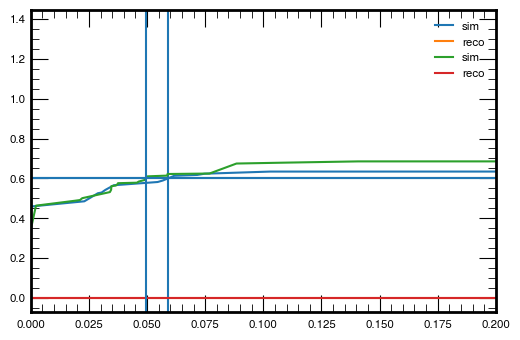

In [8]:
MAX=0.999
CUT=0.6
import time 
ts_info = []
for ev in prange(len(tracksters)):
    start = time.time()
    tsEv = tracksters[ev]
    stsEv = simtrackstersCP[ev]
    assEv = associations[ev]
    plt.figure(dpi=100)
    for stId, simEnergy in enumerate(stsEv.raw_energy):
        start = time.time()      
        score = assEv.tsCLUE3D_simToReco_CP_score[stId]
        simToReco = assEv.tsCLUE3D_simToReco_CP[stId] #[score<MAX]
        sharedE = assEv.tsCLUE3D_simToReco_CP_sharedE[stId] #[score<MAX]
        #score = score[score<MAX]

        # trackster with the higher shared energy
        refId = simToReco[np.argmax(sharedE)]
        refEta = tsEv.barycenter_eta[refId]
        refPhi = tsEv.barycenter_phi[refId]
        refEne = tsEv.raw_energy[refId]
        # sort the others by distance in eta-phi
        otherTsEta = tsEv.barycenter_eta
        otherTsPhi = tsEv.barycenter_phi
        distance = distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi)
        # distance = dist_numba_2(tsEv, refId)
        
        idx_sort = np.array(distance).argsort()
        distance_sorted = distance[idx_sort]
        tsEnergy_sorted = tsEv.raw_energy[idx_sort]
        
        sharedEnergy_sorted = assEv.tsCLUE3D_recoToSim_CP_sharedE[idx_sort]
        print(assEv.tsCLUE3D_recoToSim_CP_sharedE, sharedEnergy_sorted)
        # fill empty with zeros and then flatten before cumsum
        sharedEnergy_sorted_flatten = flatten_numba(sharedEnergy_sorted)
        # cumulative fraction of energy around ts
        fractionSimEnergy = np.cumsum(sharedEnergy_sorted_flatten)/simEnergy
        
        # cumulative pu contamination around ts
        fracRecoEnergy = 1. - sharedEnergy_sorted/tsEnergy_sorted
        fracRecoEnergy_flatten = flatten_numba(fracRecoEnergy)
        fractionRecoEnergy = np.cumsum(fracRecoEnergy_flatten)

        # stop at cut and take r
        firstAboveThrIdx = np.argmax(fractionSimEnergy>CUT)
        if max(fractionSimEnergy) < CUT:
            firstAboveThrIdx = len(fractionSimEnergy)-1
        radius = distance_sorted[firstAboveThrIdx]
        PUcont = fractionRecoEnergy[firstAboveThrIdx]
        
        ts_info.append([ev, stId, refId, refEta, refPhi, refEne, radius, PUcont])   
        
        plt.plot(distance_sorted, fractionSimEnergy, label='sim')
        plt.plot(distance_sorted, fractionRecoEnergy, label='reco')
        plt.axhline(CUT)
        plt.axvline(radius)
        plt.legend()
        # plt.xscale("log")
        plt.xlim(0,0.2)
        # assEv.tsCLUE3D_recoToSim_CP_sharedE[]
    plt.show()
    break

### multiple files

In [9]:
MAX=0.999
CUT=0.6
ts_info = []
for f in tqdm(files):
    print(f)
    filename = os.path.join(path, f)
    file = uproot.open(filename)
    alltracksters = file['ticlDumper/trackstersCLUE3DHigh;1']
    allsimtrackstersCP = file['ticlDumper/simtrackstersCP;1']
    allassociations = file['ticlDumper/associations;1']
    simtrackstersCP = allsimtrackstersCP.arrays(simTsKeys)
    tracksters = alltracksters.arrays(tsKeys)
    associations = allassociations.arrays(assKeys)
#plt.figure(dpi=100)
    for ev in prange(len(tracksters)):
        tsEv = tracksters[ev]
        stsEv = simtrackstersCP[ev]
        assEv = associations[ev]
        
        for stId, simEnergy in enumerate(stsEv.raw_energy):
            #score = assEv.tsCLUE3D_simToReco_CP_score[stId]
            simToReco = assEv.tsCLUE3D_simToReco_CP[stId] #[score<MAX]
            sharedE = assEv.tsCLUE3D_simToReco_CP_sharedE[stId] #[score<MAX]
            #score = score[score<MAX]
    
            # trackster with the higher shared energy
            if not len(sharedE):
                continue
            refId = simToReco[np.argmax(sharedE)]
            refEta = tsEv.barycenter_eta[refId]
            refPhi = tsEv.barycenter_phi[refId]
            refEne = tsEv.raw_energy[refId]
            # sort the others by distance in eta-phi
            otherTsEta = tsEv.barycenter_eta
            otherTsPhi = tsEv.barycenter_phi
            distance = dist_numba(refEta, refPhi, otherTsEta, otherTsPhi)
            # distance = dist_numba_2(tsEv, refId)

            idx_sort = np.array(distance).argsort()
            distance_sorted = distance[idx_sort]
            tsEnergy_sorted = tsEv.raw_energy[idx_sort]

            sharedEnergy_sorted = assEv.tsCLUE3D_recoToSim_CP_sharedE[idx_sort]
            # fill empty with zeros and then flatten before cumsum
            sharedEnergy_sorted_flatten = flatten_numba(sharedEnergy_sorted)
            # cumulative fraction of energy around ts
            fractionSimEnergy = np.cumsum(sharedEnergy_sorted_flatten)/simEnergy

            # cumulative pu contamination around ts
            fracRecoEnergy = 1. - sharedEnergy_sorted/tsEnergy_sorted
            fracRecoEnergy_flatten = flatten_numba(fracRecoEnergy)
            fractionRecoEnergy = np.cumsum(fracRecoEnergy_flatten)

            # stop at cut and take r
            firstAboveThrIdx = np.argmax(fractionSimEnergy>CUT)
            if max(fractionTsEnergy) < CUT:
                firstAboveThrIdx = len(fractionTsEnergy)-1
            radius = distance_sorted[firstAboveThrIdx]
            PUcont = fractionRecoEnergy[firstAboveThrIdx]

            ts_info.append([ev, stId, refId, refEta, refPhi, refEne, radius, PUcont]) 
    
            # print(radius)
            # plt.plot(distance_sorted, np.cumsum(tsEnergy_sorted)/simEnergy)
            # plt.axhline(0.8)
            # plt.axvline(radius)
            # # plt.xscale("log")
            # plt.xlim(0,0.5)
            # plt.ylim(0,2)

        


  0%|          | 0/47 [00:00<?, ?it/s]

histo_96692_0.root


  0%|          | 0/47 [00:00<?, ?it/s]


NameError: name 'fractionTsEnergy' is not defined

In [ ]:
eta = np.array(ts_info).T[3]
phi = np.array(ts_info).T[4]
ene = np.array(ts_info).T[5]
rad = np.array(ts_info).T[6]
PUc = np.array(ts_info).T[7]

In [ ]:
plt.style.use(hep.style.CMS)
scatter(abs(eta), rad, s=30, title=f'distance as a function of eta for {CUT*100:.0f}% collected energy', xlabel='eta', ylabel='R')
scatter(phi, rad, s=30, title=f'distance as a function of phi for {CUT*100:.0f}% collected energy', xlabel='phi', ylabel='R')
scatter(ene, rad, s=30, title=f'distance as a function of energy for {CUT*100:.0f}% collected energy', xlabel='Energy (GeV)', ylabel='R')
scatter(PUc, rad, s=30, title=f'distance as a function of PU contamination for {CUT*100:.0f}% collected energy', xlabel='Fraction (%)', ylabel='R')

In [ ]:
def print_avg(eta, label="variable"):
    avg_eta = np.mean(eta)
    se_eta = np.std(eta)
    print(f"Average of {label}: {avg_eta:.5f}, Error: {se_eta:.5f}")
    
# Calculate the averages
print_avg(eta, "Eta")
print_avg(phi, "Phi")
print_avg(ene, "Energy")
print_avg(PUc, "PU")